In [0]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


### Read the input file and check the data dimension

In [3]:
german_credit = pd.read_csv('/content/drive/My Drive/Machine Learning/Assignments/External/Residency 4 External Assignment/External Lab/german_credit.csv')
german_credit.head(10).T

,0,1,2,3,4,5,6,7,8,9
default,0,1,0,0,1,0,0,0,0,1
account_check_status,< 0 DM,0 <= ... < 200 DM,no checking account,< 0 DM,< 0 DM,no checking account,no checking account,0 <= ... < 200 DM,no checking account,0 <= ... < 200 DM
duration_in_month,6,48,12,42,24,36,24,36,12,30
credit_history,critical account/ other credits existing (not ...,existing credits paid back duly till now,critical account/ other credits existing (not ...,existing credits paid back duly till now,delay in paying off in the past,existing credits paid back duly till now,existing credits paid back duly till now,existing credits paid back duly till now,existing credits paid back duly till now,critical account/ other credits existing (not ...
purpose,domestic appliances,domestic appliances,(vacation - does not exist?),radio/television,car (new),(vacation - does not exist?),radio/television,car (used),domestic appliances,car (new)
credit_amount,1169,5951,2096,7882,4870,9055,2835,6948,3059,5234
savings,unknown/ no savings account,... < 100 DM,... < 100 DM,... < 100 DM,... < 100 DM,unknown/ no savings account,500 <= ... < 1000 DM,... < 100 DM,.. >= 1000 DM,... < 100 DM
present_emp_since,.. >= 7 years,1 <= ... < 4 years,4 <= ... < 7 years,4 <= ... < 7 years,1 <= ... < 4 years,1 <= ... < 4 years,.. >= 7 years,1 <= ... < 4 years,4 <= ... < 7 years,unemployed
installment_as_income_perc,4,2,2,2,3,2,3,2,2,4
personal_status_sex,male : single,female : divorced/separated/married,male : single,male : single,male : single,male : single,male : single,male : single,male : divorced/separated,male : married/widowed


In [4]:
german_credit.shape

(1000, 21)

In [5]:
german_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

In [0]:
# You can access from https://www.kaggle.com/uciml/german-credit
#Read input file and understand the data
# "default" is my dependent variable

### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [0]:
X = german_credit
y = german_credit["default"]

test_size = 0.50 
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)


In [0]:
germancredit_df = pd.DataFrame(X_train)


In [25]:
germancredit_df.head().T

,262,457,82,563,407
default,0,1,0,1,0
account_check_status,< 0 DM,< 0 DM,no checking account,0 <= ... < 200 DM,< 0 DM
duration_in_month,18,12,18,36,15
credit_history,critical account/ other credits existing (not ...,existing credits paid back duly till now,existing credits paid back duly till now,existing credits paid back duly till now,existing credits paid back duly till now
purpose,car (new),car (used),business,car (new),domestic appliances
credit_amount,5302,3386,1568,12389,1053
savings,... < 100 DM,... < 100 DM,100 <= ... < 500 DM,unknown/ no savings account,... < 100 DM
present_emp_since,.. >= 7 years,.. >= 7 years,1 <= ... < 4 years,1 <= ... < 4 years,... < 1 year
installment_as_income_perc,2,3,3,1,4
personal_status_sex,male : single,male : single,female : divorced/separated/married,male : single,male : married/widowed


In [0]:
# Lets build a Ensemble model but need to modify the dataset first


### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [30]:
germancredit_df = pd.get_dummies(germancredit_df, drop_first=True)
germancredit_df.T

,262,457,82,563,407,452,464,961,547,38,417,163,333,10,470,32,571,871,382,601,551,908,903,378,89,213,946,133,346,7,765,320,777,187,304,31,714,240,722,174,...,763,112,949,183,152,824,325,703,44,444,787,6,250,823,75,512,940,391,895,432,68,167,904,730,554,366,345,584,535,398,185,348,615,919,211,579,502,537,196,175
default,0,1,0,1,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,0,1,1,1,1,0,0,0,0,1,0,0,1,0,1,1,1,1,...,1,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1
duration_in_month,18,12,18,36,15,12,18,21,24,10,18,10,48,12,24,18,30,6,22,9,6,15,15,36,12,30,24,18,13,36,12,30,18,16,48,24,60,24,12,21,...,21,18,24,24,36,18,8,30,48,48,48,24,6,8,12,15,12,12,36,6,36,11,24,24,9,18,15,12,21,12,15,6,48,24,36,24,9,18,6,30
credit_amount,5302,3386,1568,12389,1053,2759,1950,2353,1552,1225,8471,7308,11590,1295,3092,5866,5954,1343,1283,918,1750,3594,1386,14318,1108,1908,3349,1984,882,6948,1155,4249,3509,1175,10127,4020,14027,915,1228,3414,...,12680,6260,3621,3777,5848,3780,3398,2503,6143,5096,2751,2835,666,731,1526,2687,3527,983,8947,1872,1819,1577,1278,6403,1199,3850,1459,2133,2319,1223,1360,1743,12204,3345,3835,937,1126,3612,1382,7485
installment_as_income_perc,2,3,3,1,4,2,4,1,3,2,1,2,2,3,3,2,3,1,4,4,2,1,4,4,4,4,4,4,4,2,3,4,4,2,2,2,4,4,4,2,...,4,3,2,4,4,3,1,4,4,2,4,3,3,4,4,2,2,1,3,4,4,4,4,1,4,3,4,4,2,1,4,1,2,4,2,4,2,3,1,4
present_res_since,4,4,4,4,2,4,1,4,1,2,2,4,4,1,2,2,2,4,4,1,4,2,2,2,3,4,4,4,4,2,3,2,1,3,2,2,2,2,2,1,...,4,3,4,4,1,2,4,2,4,3,3,4,4,4,4,4,3,4,2,4,4,1,1,2,4,1,2,4,1,1,2,2,2,2,4,3,4,4,1,1
age,36,35,24,37,27,34,34,47,32,37,23,70,24,25,22,30,38,46,25,30,45,46,40,57,28,66,30,47,23,35,40,28,25,68,44,27,27,29,24,26,...,30,28,31,50,24,35,39,41,58,30,38,53,39,47,66,26,45,19,31,36,37,20,36,33,67,27,43,52,33,46,31,34,48,39,45,27,49,37,28,53
credits_this_bank,3,1,1,1,1,2,2,2,1,1,2,1,2,1,1,2,1,2,1,1,1,2,1,1,2,1,1,2,2,1,2,2,1,3,1,1,1,1,1,2,...,1,1,2,1,1,2,2,2,2,1,2,1,2,2,2,1,1,1,1,3,1,1,1,1,2,2,1,1,1,2,2,2,1,1,1,2,1,1,2,1
people_under_maintenance,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,1,1,2,1,1,2,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,2,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
account_check_status_< 0 DM,1,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,1,1,...,0,0,0,0,0,0,1,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
account_check_status_>= 200 DM / salary assignments for at least 1 year,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0


In [31]:
# Print Shape of model data
germancredit_df.shape

(500, 49)

### Check for highly correlated variables but don't required any treatment for this use case

In [33]:
germancredit_df.corr()

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance,account_check_status_< 0 DM,account_check_status_>= 200 DM / salary assignments for at least 1 year,account_check_status_no checking account,credit_history_critical account/ other credits existing (not at this bank),credit_history_delay in paying off in the past,credit_history_existing credits paid back duly till now,credit_history_no credits taken/ all credits paid back duly,purpose_business,purpose_car (new),purpose_car (used),purpose_domestic appliances,purpose_education,purpose_furniture/equipment,purpose_radio/television,purpose_repairs,purpose_retraining,savings_... < 100 DM,savings_100 <= ... < 500 DM,savings_500 <= ... < 1000 DM,savings_unknown/ no savings account,present_emp_since_... < 1 year,present_emp_since_1 <= ... < 4 years,present_emp_since_4 <= ... < 7 years,present_emp_since_unemployed,personal_status_sex_male : divorced/separated,personal_status_sex_male : married/widowed,personal_status_sex_male : single,other_debtors_guarantor,other_debtors_none,"property_if not A121/A122 : car or other, not in attribute 6",property_real estate,property_unknown / no property,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,"telephone_yes, registered under the customers name",foreign_worker_yes
default,1.000000,0.259089,0.218535,0.053474,-0.041841,-0.081586,-0.061375,-0.007916,0.245368,-0.013116,-0.325050,-0.179608,0.001979,0.064564,0.110853,0.052381,0.046252,-0.121546,-0.142107,-0.010344,0.016760,0.085950,0.016760,-0.012383,0.147265,-0.011193,-0.050499,-0.137072,0.113265,0.008999,-0.108070,0.016482,0.113269,-5.314759e-02,-0.109740,-0.077210,0.012412,0.018070,-0.150162,0.136669,-0.131682,0.043955,-1.589206e-01,0.112457,0.000803,-0.002221,-0.015082,-0.032836,0.049557
duration_in_month,0.259089,1.000000,0.669686,0.061521,0.016471,-0.016886,-0.034892,-0.052569,-0.020352,-0.069055,-0.048893,-0.072281,0.191216,-0.096088,0.145428,0.199948,-0.091225,0.144163,-0.127981,-0.006922,0.148066,-0.037403,-0.018768,-0.054791,-0.093842,0.063088,-0.059154,0.131120,-0.024813,-0.004887,0.060061,-0.018781,-0.024679,-1.024666e-01,0.144248,-0.068748,0.014456,0.069349,-0.269293,0.248034,-0.128247,0.088943,-7.916794e-02,-0.066980,0.052840,-0.006085,-0.155713,0.148593,0.122827
credit_amount,0.218535,0.669686,1.000000,-0.254486,-0.024982,0.047257,-0.008663,-0.008651,-0.056465,-0.098673,-0.027248,-0.043385,0.166393,-0.105572,0.186404,0.124325,-0.015854,0.200775,-0.194202,-0.022757,0.214410,-0.024153,-0.069743,-0.077026,-0.069427,0.013338,-0.071301,0.130566,-0.050912,0.003766,0.063248,0.028110,0.027282,-1.630170e-01,0.183556,-0.100854,0.014109,0.030325,-0.243379,0.307632,-0.081737,0.037394,-1.172121e-01,-0.045493,-0.107587,-0.051660,-0.142962,0.286036,0.004987
installment_as_income_perc,0.053474,0.061521,-0.254486,1.000000,0.046631,0.005176,0.013426,-0.066527,0.066033,-0.012067,0.004990,0.026525,-0.074976,-0.010059,-0.076895,0.015560,-0.037988,-0.050575,0.093813,0.023491,-0.027125,-0.062847,0.015614,0.021029,-0.004438,-0.014921,-0.046099,0.042782,0.004991,-0.105120,0.004819,-0.073813,-0.182660,5.720089e-02,0.087391,0.064625,-0.028571,0.004004,-0.020632,0.034169,-0.018983,0.045879,2.418437e-02,-0.045652,0.047316,-0.043179,-0.061670,-0.027533,0.099614
present_res_since,-0.041841,0.016471,-0.024982,0.046631,1.000000,0.298441,0.083938,0.062531,0.099763,-0.016563,0.023275,0.102200,-0.043728,-0.082841,0.006119,-0.075164,0.054594,0.045543,-0.063447,0.001697,0.060521,-0.000984,-0.025284,-0.007735,-0.101255,0.032208,0.023841,0.105768,-0.165567,-0.130364,-0.038704,0.003577,-0.088869,-7.955179e-02,0.088419,-0.024744,0.026755,-0.066149,-0.041501,0.202814,-0.032041,-0.040351,-2.549124e-01,0.093396,-0.068720,-0.033805,0.046654,0.147116,0.025856
age,-0.081586,-0.016886,0.047257,0.005176,0.298441,1.000000,

### Drop the original variables which are converted to dummy

### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [0]:
X = germancredit_df.drop("default", axis=1)
y = germancredit_df["default"]

### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [0]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500, n_jobs = 2, criterion="entropy",random_state=9999)

In [0]:
def modelPerformanceAnalysis(X, y, model, test_size = 0.3, seed = 7):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
    model.fit(X_train, y_train)
    ### Unoptimized probability threshold based performance numbers
    # Train accuracy numbers
    trainPreds = model.predict(X_train)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    trainResults=[X_train.shape[0], trainAccuracy, trainRecall, trainPrecision, trainF1score]
    # Test accuracy numbers
    testPreds = model.predict(X_test)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    testResults=[X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score]
    
    resultsDf = pd.DataFrame( index=["dataSize", "accuracy", "recall", "precision", "f1_score"])
   
    # Concatenate Train and Test results to resultsDf
    resultsDf['unOptimalTrainResults'] = trainResults
    resultsDf['unOptimalTestResults'] = testResults
    
    return resultsDf.round(2)

In [68]:
modelPerformanceAnalysis(X, y, rf, test_size = 0.3, seed = 7)

,unOptimalTrainResults,unOptimalTestResults
dataSize,350.0,150.00
accuracy,1.0,0.73
recall,1.0,0.26
precision,1.0,0.71
f1_score,1.0,0.37


### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [69]:
y_predict = rf.predict(X_test)
metrics.confusion_matrix(y_predict, y_test)

array([[98, 35],
       [ 5, 12]])

### Q6 Show the list of the features importance( 1 Marks)

Feature ranking:
1. feature 1 (0.125224)
2. feature 0 (0.092313)
3. feature 4 (0.087226)
4. feature 9 (0.062103)
5. feature 2 (0.041379)
6. feature 3 (0.037270)
7. feature 7 (0.028065)
8. feature 33 (0.024842)
9. feature 39 (0.022624)
10. feature 5 (0.021628)
11. feature 23 (0.021410)
12. feature 43 (0.020469)
13. feature 37 (0.019926)
14. feature 46 (0.019164)
15. feature 10 (0.018578)
16. feature 41 (0.018282)
17. feature 26 (0.017970)
18. feature 6 (0.017597)
19. feature 36 (0.017152)
20. feature 12 (0.016623)
21. feature 28 (0.016369)
22. feature 17 (0.016368)
23. feature 27 (0.015712)
24. feature 15 (0.015678)
25. feature 29 (0.015129)
26. feature 38 (0.014405)
27. feature 20 (0.014220)
28. feature 45 (0.013857)
29. feature 42 (0.012924)
30. feature 11 (0.011144)
31. feature 35 (0.010807)
32. feature 14 (0.010770)
33. feature 16 (0.010492)
34. feature 32 (0.010425)
35. feature 8 (0.010364)
36. feature 24 (0.009095)
37. feature 40 (0.008949)
38. feature 34 (0.007795)
39. feature 13

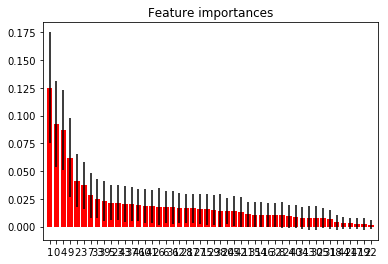

In [94]:
rf.feature_importances_

importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_],
             axis=0)
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")

for f in range(X.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))

# Plot the feature importances of the forest
plt.figure()
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices],
       color="r", yerr=std[indices], align="center")
plt.xticks(range(X.shape[1]), indices)
plt.xlim([-1, X.shape[1]])
plt.show()

### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [0]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn import model_selection

In [0]:
# Use below values
num_folds = 10
seed = 77

In [0]:
#Validate the Random Forest model build above using k fold

In [0]:
kfold = model_selection.KFold(n_splits=10,random_state=seed)
cv_results = model_selection.cross_val_score(rf, X, y, cv=kfold, scoring='accuracy')

In [86]:
cv_results

array([0.66, 0.82, 0.72, 0.78, 0.7 , 0.8 , 0.66, 0.72, 0.78, 0.76])

In [0]:
#Calculate Mean score

In [88]:
cv_results.mean()

0.74

In [0]:
# Calculate score standard deviation using std()

In [90]:
cv_results.std()

0.05366563145999495

# Q8 Print the confusion matrix( 1 Marks)

In [65]:
metrics.confusion_matrix(y_predict, y_test)

array([[98, 35],
       [ 5, 12]])

# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [78]:
modelPerformanceAnalysis(X, y, rf, test_size = 0.3, seed = 7)

,unOptimalTrainResults,unOptimalTestResults
dataSize,350.0,150.00
accuracy,1.0,0.73
recall,1.0,0.26
precision,1.0,0.71
f1_score,1.0,0.37


# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [0]:
#Hint: Use roc_curve
from sklearn.metrics import roc_curve, auc

In [82]:
y_predictProb = rf.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_predictProb[::,1])
roc_auc = auc(fpr, tpr)
roc_auc

0.7606899400950218

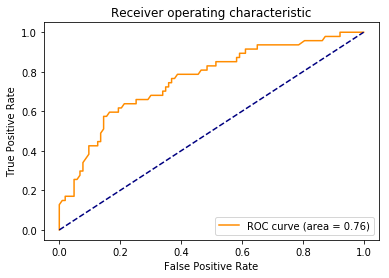

In [83]:
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [0]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [0]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    rfm.fit(X_, y_)
    y_pred = rfm.predict(X_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [0]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())

Accuracy Score
Avearge:  0.6893333333333334
Standard deviation:  0.014966629547095768
